# Cyclic Schematic Graph

使用 networkx 检测图的 minimum cycle basis，并构建 cyclic schematic graph。

In [1]:
import networkx as nx
import matplotlib.pyplot as plt
from collections import defaultdict

print(f"networkx version: {nx.__version__}")

networkx version: 3.5


## 核心算法函数

In [2]:
def get_cycle_edges(cycle):
    """将 cycle（节点列表）转换为边集合（每条边用 frozenset 表示，无向）。"""
    edges = set()
    n = len(cycle)
    for i in range(n):
        u = cycle[i]
        v = cycle[(i + 1) % n]
        edges.add(frozenset([u, v]))
    return edges
def get_edge_in_cycle(cycle):
    """将 cycle 转换为 (u, v) 形式的元组边列表（用于判断边是否属于某 cycle）。"""
    edges = []
    n = len(cycle)
    for i in range(n):
        u = cycle[i]
        v = cycle[(i + 1) % n]
        edges.append((u, v) if str(u) <= str(v) else (v, u))
    return edges
def cyclic_schematic_graph(G, cb_prefix="CB"):
    """
    从输入图 G 构建 cyclic schematic graph。
    参数
    ----------
    G : networkx.Graph
        输入无向图。
    返回
    -------
    H : networkx.Graph
        Cyclic schematic graph。节点属性:
          - type: 'cycle_basis' | 'original_non_cycle' | 'interface'
          - 若 type='cycle_basis': 还有 cycle_index, original_nodes 属性
    cycle_basis : list
        minimum cycle basis 列表（每个 cycle 是节点列表）。
    info : dict
        额外信息。
    """
    # ============================================================
    # Step 1: 检测 minimum cycle basis
    # ============================================================
    raw_basis = nx.minimum_cycle_basis(G)
    cycle_basis = [list(c) for c in raw_basis]
    # 找出出现在至少一个 cycle basis 中的节点和边
    nodes_in_cycles = set()
    edges_in_cycles = set()  # 存储为 (min, max) 元组
    for cycle in cycle_basis:
        nodes_in_cycles.update(cycle)
        for u, v in get_edge_in_cycle(cycle):
            edges_in_cycles.add((u, v) if str(u) <= str(v) else (v, u))
    # 不出现在任何 cycle basis 中的节点
    nodes_not_in_cycles = set(G.nodes()) - nodes_in_cycles
    # 不出现在任何 cycle basis 中的边
    edges_not_in_cycles = []
    for u, v in G.edges():
        key = (u, v) if str(u) <= str(v) else (v, u)
        if key not in edges_in_cycles:
            edges_not_in_cycles.append((u, v))
    # ============================================================
    # Step 2: 构建初始 cyclic schematic graph
    # ============================================================
    H = nx.Graph()
    # 添加 cycle basis 节点
    num_bases = len(cycle_basis)
    for i in range(num_bases):
        H.add_node(
            f"{cb_prefix}_{i}",
            type="cycle_basis",
            cycle_index=i,
            original_nodes=cycle_basis[i],
        )
    # 如果两个 cycle basis 至少共享一条边，则在它们之间添加边
    basis_edge_sets = [get_cycle_edges(c) for c in cycle_basis]
    for i in range(num_bases):
        for j in range(i + 1, num_bases):
            if basis_edge_sets[i] & basis_edge_sets[j]:
                H.add_edge(f"{cb_prefix}_{i}", f"{cb_prefix}_{j}")
    # 添加不出现在任何 cycle basis 中的节点
    for node in nodes_not_in_cycles:
        H.add_node(node, type="original_non_cycle")
    # 添加不出现在任何 cycle basis 中的边
    # 第一类：两端点都不在任何 cycle basis 中 → 直接加入
    # 第二类至少一个端点在 cycle 中 → Step 3 处理，此处跳过
    for u, v in edges_not_in_cycles:
        if u in nodes_not_in_cycles and v in nodes_not_in_cycles:
            H.add_edge(u, v)
    # ============================================================
    # Step 3: 识别接口结点并构建 cyclic schematic graph
    # ============================================================
    # 找到 cycle basis 节点构成的连通分支（圈簇）
    cb_nodes = [f"{cb_prefix}_{i}" for i in range(num_bases)]
    if cb_nodes:
        cb_subgraph = H.subgraph(cb_nodes)
        clusters = list(nx.connected_components(cb_subgraph))
        # clusters 中的每个元素是 CB 节点名（如 'CB_0'）的集合
    else:
        clusters = []
    # 将 cluster 转换为每个 CB 节点所属 cluster 的映射
    cb_to_cluster = {}
    for cluster_id, cluster in enumerate(clusters):
        for cb_node in cluster:
            cb_to_cluster[cb_node] = cluster_id
    # 记录已添加的接口结点
    interface_nodes_added = set()
    # --- 情况1：两个圈簇之间的公共结点 ---
    # 两个圈簇之间只可能有1个公共结点
    for a in range(len(clusters)):
        for b in range(a + 1, len(clusters)):
            # 获取 cluster a 中所有 cycle 包含的原始节点
            nodes_in_cluster_a = set()
            for cb_node in clusters[a]:
                idx = int(cb_node.split("_")[1])
                nodes_in_cluster_a.update(cycle_basis[idx])
            nodes_in_cluster_b = set()
            for cb_node in clusters[b]:
                idx = int(cb_node.split("_")[1])
                nodes_in_cluster_b.update(cycle_basis[idx])
            common_nodes = nodes_in_cluster_a & nodes_in_cluster_b
            if len(common_nodes) == 1:
                v = list(common_nodes)[0]
                # 将接口结点加入 cyclic schematic graph
                if v not in H:
                    H.add_node(v, type="interface")
                    interface_nodes_added.add(v)
                # 接口结点与 cluster a 建边（只连1条边到包含该节点的第一个 CB）
                for cb_node in clusters[a]:
                    idx = int(cb_node.split("_")[1])
                    if v in cycle_basis[idx]:
                        H.add_edge(v, cb_node)
                        break
                # 接口结点与 cluster b 建边（只连1条边到包含该节点的第一个 CB）
                for cb_node in clusters[b]:
                    idx = int(cb_node.split("_")[1])
                    if v in cycle_basis[idx]:
                        H.add_edge(v, cb_node)
                        break
    # --- 情况2：处理第二类边 ---
    # 边的两个端点中，一个出现在某个 cycle basis 中（接口结点），另一个不出现在任何 cycle basis 中
    for u, v in edges_not_in_cycles:
        u_in_cycle = u in nodes_in_cycles
        v_in_cycle = v in nodes_in_cycles
        if u_in_cycle and not v_in_cycle:
            # u 是接口结点（出现在 cycle basis 中）
            if u not in H:
                H.add_node(u, type="interface")
                interface_nodes_added.add(u)
            # 加入原边 (u, v)
            H.add_edge(u, v)
            # 连接到包含 u 的每个 cycle basis
            for i, cycle in enumerate(cycle_basis):
                if u in cycle:
                    H.add_edge(u, f"{cb_prefix}_{i}")
        elif v_in_cycle and not u_in_cycle:
            # v 是接口结点（出现在 cycle basis 中）
            if v not in H:
                H.add_node(v, type="interface")
                interface_nodes_added.add(v)
            # 加入原边 (u, v)
            H.add_edge(u, v)
            # 连接到包含 v 的每个 cycle basis
            for i, cycle in enumerate(cycle_basis):
                if v in cycle:
                    H.add_edge(v, f"{cb_prefix}_{i}")

        elif u_in_cycle and v_in_cycle:
            # --- 情况3：第三类边 ---
            # 边的两个关联结点分别出现在两个 minimum cycle basis 中
            # 这两个关联节点都是接口结点
            if u not in H:
                H.add_node(u, type="interface")
                interface_nodes_added.add(u)
            if v not in H:
                H.add_node(v, type="interface")
                interface_nodes_added.add(v)
            # 加入原边 (u, v)
            H.add_edge(u, v)
            # 连接到包含 u 的每个 cycle basis
            for i, cycle in enumerate(cycle_basis):
                if u in cycle:
                    H.add_edge(u, f"{cb_prefix}_{i}")
            # 连接到包含 v 的每个 cycle basis
            for i, cycle in enumerate(cycle_basis):
                if v in cycle:
                    H.add_edge(v, f"{cb_prefix}_{i}")
    # ============================================================
    # 整理结果信息
    # ============================================================
    info = {
        "cycle_basis": cycle_basis,
        "nodes_in_cycles": nodes_in_cycles,
        "nodes_not_in_cycles": nodes_not_in_cycles,
        "edges_in_cycles": edges_in_cycles,
        "edges_not_in_cycles": edges_not_in_cycles,
        "clusters": clusters,
        "interface_nodes_added": interface_nodes_added,
    }
    return H, cycle_basis, info


## 绘图函数

In [3]:
def draw_input_graph(G, ax=None, title="Input Graph"):
    """绘制输入图。"""
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 6))
    else:
        fig = ax.figure

    pos = nx.spring_layout(G, seed=42)
    nx.draw_networkx_nodes(G, pos, ax=ax, node_color="lightblue",
                           node_size=500, edgecolors="black")
    nx.draw_networkx_edges(G, pos, ax=ax, width=1.5, alpha=0.7)
    nx.draw_networkx_labels(G, pos, ax=ax, font_size=10, font_weight="bold")

    ax.set_title(title, fontsize=14, fontweight="bold")
    ax.axis("off")
    return fig


def draw_cyclic_schematic(H, cycle_basis, info, ax=None, title="Cyclic Schematic Graph"):
    """绘制 cyclic schematic graph。不同节点类型使用不同颜色和形状。"""
    if ax is None:
        fig, ax = plt.subplots(figsize=(12, 8))
    else:
        fig = ax.figure

    # 按类型分组节点
    cb_nodes = [n for n, d in H.nodes(data=True) if d.get("type") == "cycle_basis"]
    orig_non_cycle = [n for n, d in H.nodes(data=True) if d.get("type") == "original_non_cycle"]
    interface_nodes = [n for n, d in H.nodes(data=True) if d.get("type") == "interface"]

    # 布局
    pos = nx.spring_layout(H, seed=42, k=2, iterations=50)

    # 绘制边
    nx.draw_networkx_edges(H, pos, ax=ax, width=1.2, alpha=0.5, edge_color="gray")

    # 绘制 cycle basis 节点（蓝色圆）
    if cb_nodes:
        nx.draw_networkx_nodes(
            H, pos, nodelist=cb_nodes, ax=ax,
            node_color="#4A90D9", node_size=800,
            edgecolors="#2C5F8A", linewidths=2,
        )

    # 绘制原始非 cycle 节点（绿色方）
    if orig_non_cycle:
        nx.draw_networkx_nodes(
            H, pos, nodelist=orig_non_cycle, ax=ax,
            node_color="#7DD67D", node_size=600,
            edgecolors="#2E8B2E", linewidths=2,
            node_shape="s",
        )

    # 绘制接口结点（红色菱）
    if interface_nodes:
        nx.draw_networkx_nodes(
            H, pos, nodelist=interface_nodes, ax=ax,
            node_color="#FF6B6B", node_size=700,
            edgecolors="#CC3333", linewidths=2,
            node_shape="d",
        )

    # 标签
    labels = {}
    for n in H.nodes():
        d = H.nodes[n]
        if d.get("type") == "cycle_basis":
            labels[n] = n  # e.g., "CB_0"
        else:
            labels[n] = str(n)

    nx.draw_networkx_labels(H, pos, labels=labels, ax=ax,
                            font_size=9, font_weight="bold")

    # 图例
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor="#4A90D9", edgecolor="#2C5F8A", label="Cycle Basis (CB)"),
        Patch(facecolor="#7DD67D", edgecolor="#2E8B2E", label="Original Node (not in cycles)"),
        Patch(facecolor="#FF6B6B", edgecolor="#CC3333", label="Interface Node"),
    ]
    ax.legend(handles=legend_elements, loc="upper right", fontsize=10)

    ax.set_title(title, fontsize=14, fontweight="bold")
    ax.axis("off")
    return fig


def draw_side_by_side(G, H, cycle_basis, info):
    """并排绘制输入图和 cyclic schematic graph。"""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))

    draw_input_graph(G, ax=ax1, title="(a) Input Graph")
    draw_cyclic_schematic(H, cycle_basis, info, ax=ax2,
                          title="(b) Cyclic Schematic Graph")

    plt.tight_layout()
    plt.show()
    return fig


## 带 Cycle 高亮的绘图函数

输入图中，使用不同颜色区别每个 minimum cycle basis 对应的圈（cycle）中的节点；属于多个 cycle 的节点用金色高亮。

In [4]:
def draw_input_graph_with_cycles(G, cycle_basis, ax=None, title="Input Graph (cycle-highlighted)", cb_prefix="CB"):
    """
    绘制输入图，并用不同颜色区分不同 cycle basis 中的节点。
    每个 cycle basis 使用独立颜色，属于多个 cycle 的节点用金色高亮。
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 6))
    else:
        fig = ax.figure

    pos = nx.spring_layout(G, seed=42)

    # 构建 node -> cycle indices 映射
    node_cycles = defaultdict(list)
    for i, cycle in enumerate(cycle_basis):
        for node in cycle:
            node_cycles[node].append(i)

    cycle_colors = plt.cm.tab10.colors  # 最多10种不同颜色

    # 绘制边
    nx.draw_networkx_edges(G, pos, ax=ax, width=1.5, alpha=0.7, edge_color="gray")

    # 不在任何 cycle 中的节点（浅蓝色）
    non_cycle_nodes = [n for n in G.nodes() if n not in node_cycles]
    if non_cycle_nodes:
        nx.draw_networkx_nodes(G, pos, nodelist=non_cycle_nodes, ax=ax,
                                node_color="lightblue", node_size=500, edgecolors="black")

    # 按所属 cycle 分组绘制节点
    single_cycle_nodes_by_color = defaultdict(list)
    multi_cycle_nodes = []
    for node, cycles in node_cycles.items():
        if len(cycles) == 1:
            single_cycle_nodes_by_color[cycles[0]].append(node)
        else:
            multi_cycle_nodes.append(node)

    # 属于单个 cycle 的节点：用该 cycle 的颜色
    for cycle_idx, nodes in single_cycle_nodes_by_color.items():
        color = cycle_colors[cycle_idx % len(cycle_colors)]
        nx.draw_networkx_nodes(G, pos, nodelist=nodes, ax=ax,
                                node_color=[color], node_size=500, edgecolors="black")

    # 属于多个 cycle 的节点：金色菱形 + 红边
    if multi_cycle_nodes:
        nx.draw_networkx_nodes(G, pos, nodelist=multi_cycle_nodes, ax=ax,
                                node_color="gold", node_size=550,
                                edgecolors="red", linewidths=2, node_shape="d")

    nx.draw_networkx_labels(G, pos, ax=ax, font_size=10, font_weight="bold")

    # 图例
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor="#4A90D9", edgecolor="#2C5F8A", label="Cycle Basis (CB)"),
        Patch(facecolor="#7DD67D", edgecolor="#2E8B2E", label="Original Node (not in cycles)"),
        Patch(facecolor="#FF6B6B", edgecolor="#CC3333", label="Interface Node"),
    ]

    ax.legend(handles=legend_elements, loc="upper right", fontsize=9, framealpha=0.8)
    ax.set_title(title, fontsize=14, fontweight="bold")
    ax.axis("off")
    return fig


def draw_side_by_side_with_cycles(G, H, cycle_basis, info, cb_prefix="CB"):
    """
    并排绘制带 cycle 高亮的输入图和 cyclic schematic graph。
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(22, 9))

    draw_input_graph_with_cycles(G, cycle_basis, ax=ax1,
                                 title="(a) Input Graph (cycle-highlighted)", cb_prefix=cb_prefix)
    draw_cyclic_schematic(H, cycle_basis, info, ax=ax2,
                          title="(b) Cyclic Schematic Graph")

    plt.tight_layout()
    plt.show()
    return fig

## 信息展示函数

In [5]:
def print_analysis_info(G, H, cycle_basis, info):
    """打印详细的分析信息。"""
    print("=" * 60)
    print("图分析报告")
    print("=" * 60)

    print(f"\n输入图: {G.number_of_nodes()} 个节点, {G.number_of_edges()} 条边")

    print(f"\n--- Step 1: Minimum Cycle Basis ---")
    print(f"检测到 {len(cycle_basis)} 个 minimum cycle basis:")
    # Extract cb_prefix from actual node names in H
    cb_nodes_h = [n for n, d in H.nodes(data=True) if d.get("type") == "cycle_basis"]
    cb_prefix = cb_nodes_h[0].rsplit("_", 1)[0] if cb_nodes_h else "CB"
    for i, cycle in enumerate(cycle_basis):
        print(f"  {cb_prefix}_{i}: {cycle}")
        ce = get_edge_in_cycle(cycle)
        print(f"         边: {ce}")

    print(f"\n出现在任意 cycle basis 中的节点: {sorted(info['nodes_in_cycles'], key=str)}")
    print(f"不出现在任意 cycle basis 中的节点: {sorted(info['nodes_not_in_cycles'], key=str)}")
    print(f"不出现在任意 cycle basis 中的边:")
    for e in info['edges_not_in_cycles']:
        print(f"  {e}")

    print(f"\n--- Step 2: 初始 Cyclic Schematic Graph ---")
    print(f"H 节点数: {H.number_of_nodes()}, 边数: {H.number_of_edges()}")

    print(f"\n--- Step 3: 圈簇与接口结点 ---")
    clusters = info['clusters']
    print(f"存在 {len(clusters)} 个圈簇 (CB-only 连通分支):")
    for i, cluster in enumerate(clusters):
        nodes_in_cluster = set()
        for cb_node in cluster:
            idx = int(cb_node.split("_")[1])
            nodes_in_cluster.update(cycle_basis[idx])
        print(f"  圈簇 {i}: CB节点={sorted(cluster, key=str)}, 包含原始节点={sorted(nodes_in_cluster, key=str)}")

    if info['interface_nodes_added']:
        print(f"接口结点: {sorted(info['interface_nodes_added'], key=str)}")
    else:
        print(f"接口结点: 无")

    print(f"\n最终 Cyclic Schematic Graph:")
    print(f"  H 节点数: {H.number_of_nodes()}, 边数: {H.number_of_edges()}")
    print(f"  节点列表: {list(H.nodes())}")
    print(f"  边列表: {list(H.edges())}")
    print("=" * 60)

## 示例 1：基础测试图

包含多个共享边的 cycle、孤立节点（不在任何 cycle 中）、以及第二类边。

In [6]:
# 构建测试图

G1 = nx.Graph()

# 上排网格的边
G1.add_edges_from([
    (0, 2), (0, 3), (0, 4), (0, 18), (0, 19), (0, 25),
    (1, 2), (1, 5), (1, 7), (1, 4), 
    (2, 3), (2, 5), 
    (3, 4), (3, 7), 
    (4, 5), (4, 6), 
    (5, 14), 
    (6, 7), (6, 14), 
    (7, 14), 
    (8, 11), (8, 15), 
    (9, 11), (9, 12), 
    (10, 12), (10, 13), 
    (11, 12), (11, 16), 
    (12, 13), (12, 16), (12, 17), 
    (13, 17), 
    (18, 19), 
    (20, 21), (20, 25), 
    (21, 25), 
    (22, 23), (22, 25), 
    (23, 24), (23, 25), 
    (24, 25)
])

print(f"输入图 G1: {G1.number_of_nodes()} 节点, {G1.number_of_edges()} 边")
print(f"节点: {sorted(G1.nodes())}")
print(f"边: {sorted(G1.edges())}")

输入图 G1: 26 节点, 41 边
节点: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25]
边: [(0, 2), (0, 3), (0, 4), (0, 18), (0, 19), (0, 25), (1, 5), (1, 7), (2, 1), (2, 3), (2, 5), (3, 4), (3, 7), (4, 1), (4, 5), (4, 6), (5, 14), (6, 14), (7, 6), (7, 14), (8, 11), (8, 15), (9, 12), (10, 13), (11, 9), (11, 12), (11, 16), (12, 10), (12, 13), (12, 16), (12, 17), (13, 17), (18, 19), (20, 21), (22, 23), (23, 24), (25, 20), (25, 21), (25, 22), (25, 23), (25, 24)]


图分析报告

输入图: 26 个节点, 41 条边

--- Step 1: Minimum Cycle Basis ---
检测到 17 个 minimum cycle basis:
  cb0_0: [20, 21, 25]
         边: [(20, 21), (21, 25), (20, 25)]
  cb0_1: [23, 24, 25]
         边: [(23, 24), (24, 25), (23, 25)]
  cb0_2: [6, 14, 7]
         边: [(14, 6), (14, 7), (6, 7)]
  cb0_3: [3, 7, 1, 2]
         边: [(3, 7), (1, 7), (1, 2), (2, 3)]
  cb0_4: [1, 5, 4]
         边: [(1, 5), (4, 5), (1, 4)]
  cb0_5: [2, 3, 0]
         边: [(2, 3), (0, 3), (0, 2)]
  cb0_6: [22, 23, 25]
         边: [(22, 23), (23, 25), (22, 25)]
  cb0_7: [18, 19, 0]
         边: [(18, 19), (0, 19), (0, 18)]
  cb0_8: [7, 6, 4, 3]
         边: [(6, 7), (4, 6), (3, 4), (3, 7)]
  cb0_9: [6, 14, 5, 4]
         边: [(14, 6), (14, 5), (4, 5), (4, 6)]
  cb0_10: [4, 1, 2, 0]
         边: [(1, 4), (1, 2), (0, 2), (0, 4)]
  cb0_11: [1, 5, 2]
         边: [(1, 5), (2, 5), (1, 2)]
  cb0_12: [3, 4, 0]
         边: [(3, 4), (0, 4), (0, 3)]
  cb0_13: [13, 17, 12]
         边: [(13, 17), (12, 17), (12, 13)]
  cb0_14: [12, 13, 10]
    

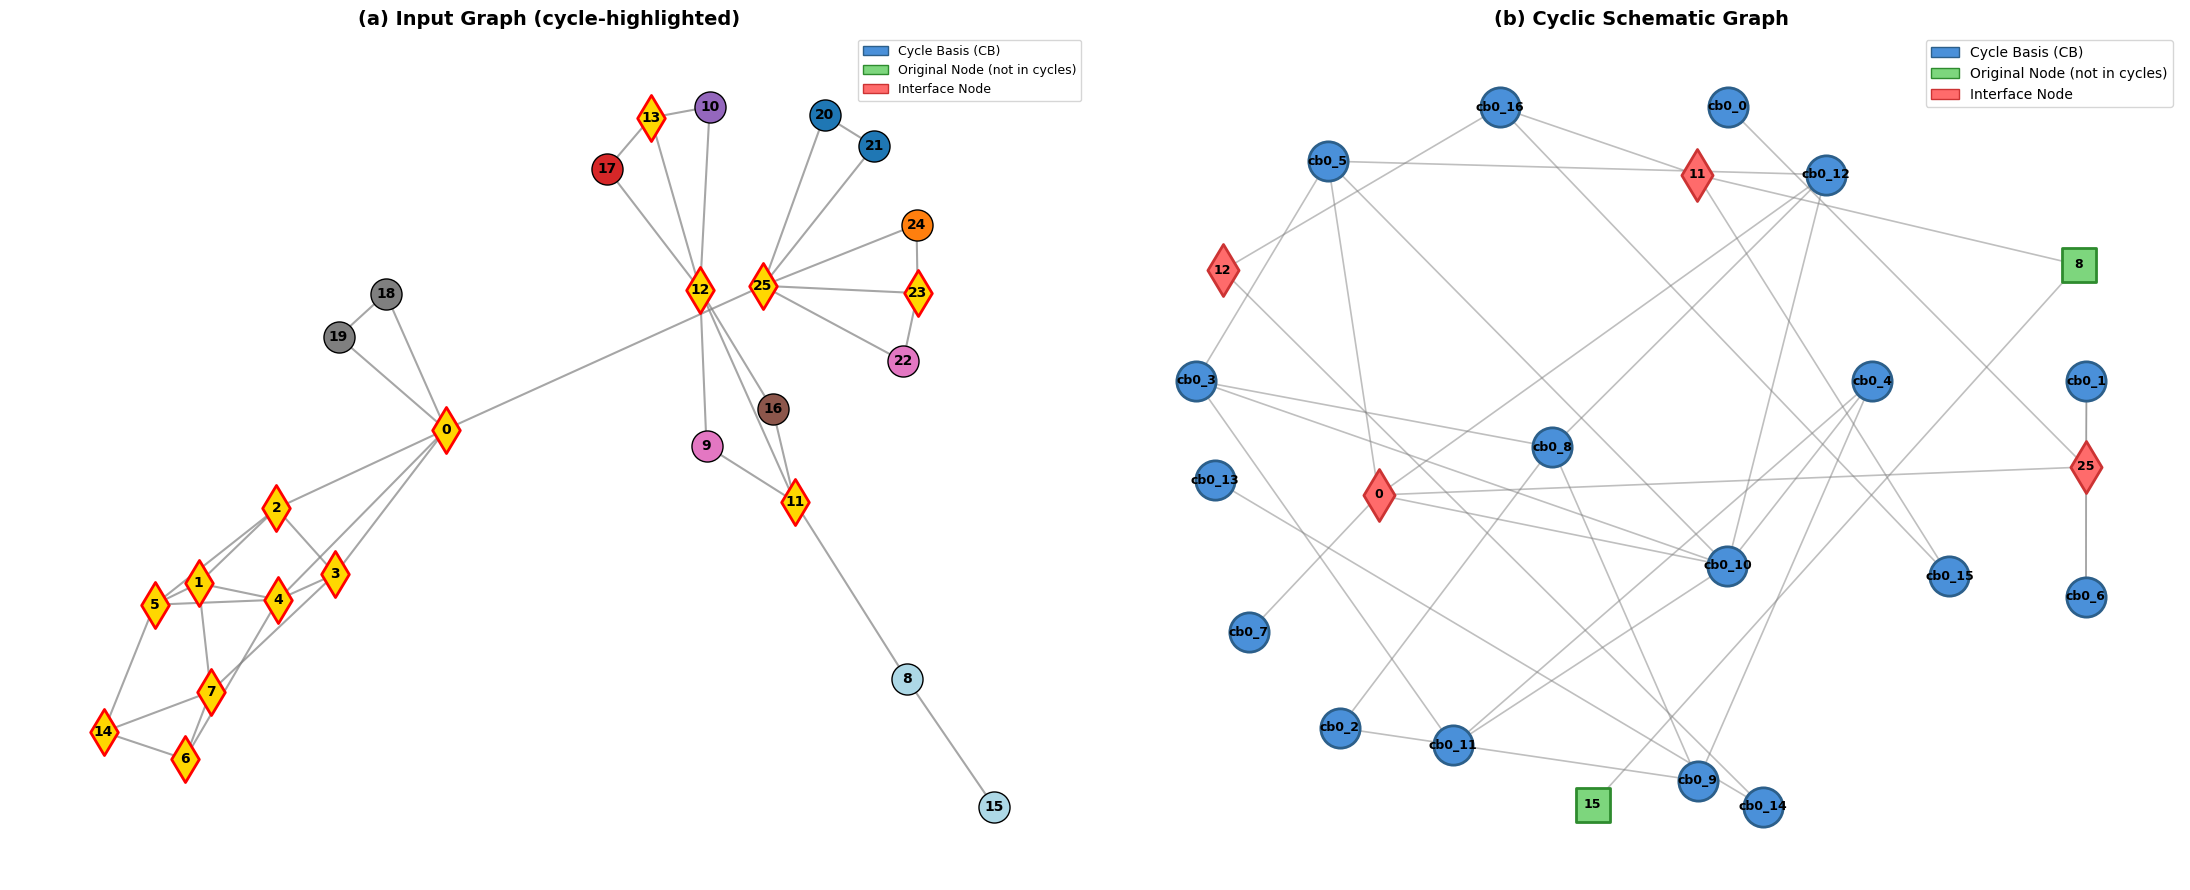

图分析报告

输入图: 23 个节点, 32 条边

--- Step 1: Minimum Cycle Basis ---
检测到 11 个 minimum cycle basis:
  cb1_0: ['cb0_8', 'cb0_9', 'cb0_2']
         边: [('cb0_8', 'cb0_9'), ('cb0_2', 'cb0_9'), ('cb0_2', 'cb0_8')]
  cb1_1: ['cb0_5', 'cb0_10', 'cb0_3']
         边: [('cb0_10', 'cb0_5'), ('cb0_10', 'cb0_3'), ('cb0_3', 'cb0_5')]
  cb1_2: ['cb0_10', 'cb0_12', 'cb0_5']
         边: [('cb0_10', 'cb0_12'), ('cb0_12', 'cb0_5'), ('cb0_10', 'cb0_5')]
  cb1_3: ['cb0_12', 0, 'cb0_5']
         边: [(0, 'cb0_12'), (0, 'cb0_5'), ('cb0_12', 'cb0_5')]
  cb1_4: ['cb0_10', 'cb0_11', 'cb0_4']
         边: [('cb0_10', 'cb0_11'), ('cb0_11', 'cb0_4'), ('cb0_10', 'cb0_4')]
  cb1_5: ['cb0_6', 25, 'cb0_1']
         边: [(25, 'cb0_6'), (25, 'cb0_1'), ('cb0_1', 'cb0_6')]
  cb1_6: ['cb0_10', 0, 'cb0_5']
         边: [(0, 'cb0_10'), (0, 'cb0_5'), ('cb0_10', 'cb0_5')]
  cb1_7: ['cb0_10', 'cb0_11', 'cb0_3']
         边: [('cb0_10', 'cb0_11'), ('cb0_11', 'cb0_3'), ('cb0_10', 'cb0_3')]
  cb1_8: ['cb0_8', 'cb0_9', 'cb0_4', 'cb0_10', 'cb0

In [7]:
# 执行算法并保存中间图
NUM_ITERATIONS = 5  # User-specified iteration count

# Initial cyclic schematic graph (iteration 0) with cb0_ prefix
H, cycle_basis, info = cyclic_schematic_graph(G1, cb_prefix="cb0")

# 打印分析信息
print_analysis_info(G1, H, cycle_basis, info)

# Save initial Cyclic Schematic Graph (iteration 0)
fig = draw_cyclic_schematic(H, cycle_basis, info, title="Iter 0: Cyclic Schematic of G1")
fig.savefig("/home/harryzhou/cyclic_schema/example1_iter_0.png", dpi=150, bbox_inches="tight")
plt.close(fig)

# Save comparison of input graph and initial cyclic schematic graph
fig = draw_side_by_side_with_cycles(G1, H, cycle_basis, info)
fig.savefig("/home/harryzhou/cyclic_schema/example1_initial_comparison.png", dpi=150, bbox_inches="tight")
plt.close(fig)

# Iteratively refine: use the cyclic schematic graph as input for next iteration
for iteration in range(1, NUM_ITERATIONS + 1):
    H_next, cycle_basis_next, info_next = cyclic_schematic_graph(H, cb_prefix=f"cb{iteration}")
    print_analysis_info(H, H_next, cycle_basis_next, info_next)

    # Save current iteration's Cyclic Schematic Graph
    fig = draw_cyclic_schematic(H_next, cycle_basis_next, info_next, title=f"Iter {iteration}: Cyclic Schematic")
    fig.savefig(f"/home/harryzhou/cyclic_schema/example1_iter_{iteration}.png", dpi=150, bbox_inches="tight")
    plt.close(fig)

    H = H_next
    cycle_basis = cycle_basis_next
    info = info_next

## 示例 2：Zachary's Karate Club 图

使用 networkx 内置的 Karate Club 图（经典社交网络图，34 个节点，78 条边）。

In [8]:
# # 使用 Zachary's Karate Club 图（经典的社交网络图）
# # 34 个节点，78 条边，networkx 内置数据集
# G2 = nx.karate_club_graph()

# NUM_ITERATIONS = 4

# print(f"输入图 G2 (Karate Club): {G2.number_of_nodes()} 节点, {G2.number_of_edges()} 边")
# print(f"节点: {sorted(G2.nodes())}")
# print(f"迭代次数: {NUM_ITERATIONS}")

In [9]:
# # 执行算法并保存中间图
# H2, cycle_basis2, info2 = cyclic_schematic_graph(G2)

# # 打印分析信息
# print_analysis_info(G2, H2, cycle_basis2, info2)

# # Save initial Cyclic Schematic Graph (iteration 0)
# fig = draw_cyclic_schematic(H2, cycle_basis2, info2, title="Iter 0: Cyclic Schematic of Karate Club")
# fig.savefig("/home/harryzhou/cyclic_schema/example2_iter_0.png", dpi=150, bbox_inches="tight")
# plt.close(fig)

# # 保存输入图与初始 cyclic schematic graph 的对比图
# fig = draw_side_by_side_with_cycles(G2, H2, cycle_basis2, info2)
# fig.savefig("/home/harryzhou/cyclic_schema/example2_initial_comparison.png", dpi=150, bbox_inches="tight")
# plt.close(fig)

# # 注意: Karate Club 图的 iterative refinement 会使图爆炸式增长(132→454节点),
# # 因此只生成初始 Cyclic Schematic Graph (Iter 0) 和对比图。
# print("\n[NOTE] Example 2 只生成 Iter 0 (初始图), iterative loop 跳过。")